<a href="https://colab.research.google.com/github/leah-mogotsi/leah-s-portfolio-projects/blob/main/Leah_Loan_DRP_ML_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 1: Alpha Dreamers Banking Consortium**


**Project Scenario & problem :** Alpha Dreamers Banking Consortium is experiencing a high rate of personal loan defaults, and they need a system to identify and predict customers who are likely to default in order to reduce financial losses and improve loan decision-making.

**Project goal:** The final goal is to develop a machine learning model capable of supporting credit risk assessment by flagging potentially high-risk customers.


**Hypothetical questions:**

1. **Does marital status influence loan default risk?**
2. **Which age groups are most likely to apply for loans, and does age significantly influence the likelihood of loan default?**
3. **Does owning an asset like a car affect loan default risk?**


## **1. Data Analysis**

In [1]:
#1 Import the relevant dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/CSEdata.csv")

In [3]:
df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3.0,13.0,0.0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9.0,13.0,0.0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4.0,10.0,0.0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2.0,12.0,1.0
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3.0,14.0,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39808 entries, 0 to 39807
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id                 39808 non-null  int64  
 1   Income             39808 non-null  int64  
 2   Age                39808 non-null  int64  
 3   Experience         39808 non-null  int64  
 4   Married/Single     39808 non-null  object 
 5   House_Ownership    39808 non-null  object 
 6   Car_Ownership      39808 non-null  object 
 7   Profession         39808 non-null  object 
 8   CITY               39807 non-null  object 
 9   STATE              39807 non-null  object 
 10  CURRENT_JOB_YRS    39807 non-null  float64
 11  CURRENT_HOUSE_YRS  39807 non-null  float64
 12  Risk_Flag          39807 non-null  float64
dtypes: float64(3), int64(4), object(6)
memory usage: 3.9+ MB


In [5]:
df.describe()

,Id,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
count,39808.000000,3.980800e+04,39808.000000,39808.000000,39807.000000,39807.000000,39807.000000
mean,19904.500000,5.005572e+06,50.029542,10.106863,6.340041,11.993569,0.132489
std,11491.724095,2.877373e+06,17.051929,6.003259,3.649641,1.395386,0.339026
min,1.000000,1.031000e+04,21.000000,0.000000,0.000000,10.000000,0.000000
25%,9952.750000,2.511105e+06,35.000000,5.000000,4.000000,11.000000,0.000000
50%,19904.500000,5.013716e+06,50.000000,10.000000,6.000000,12.000000,0.000000
75%,29856.250000,7.479878e+06,65.000000,15.000000,9.000000,13.000000,0.000000
max,39808.000000,9.999180e+06,79.000000,20.000000,14.000000,14.000000,1.000000


In [6]:
df.shape

(39808, 13)

## **2. Data Cleaning & Preparation**

In [7]:
#Checking for missing values
df.isnull().sum()

,0
Id,0
Income,0
Age,0
Experience,0
Married/Single,0
House_Ownership,0
Car_Ownership,0
Profession,0
CITY,1
STATE,1


In [8]:
#Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
#Getting rid of inconsistencies within the categorical data that is likely to have high cardinality
cols_to_clean = ["CITY", "STATE", "Profession"]

for col in cols_to_clean:
    df[col] = (
        df[col]
        .str.replace(r"\[.*?\]", "", regex=True)
        .str.strip()
        .str.title()
    )

## **3. Data Visualization**

### **3.1 Default Risk Distribution**

Shows the number of risky vs safe customers. This helps the bank understand the overall default rate.

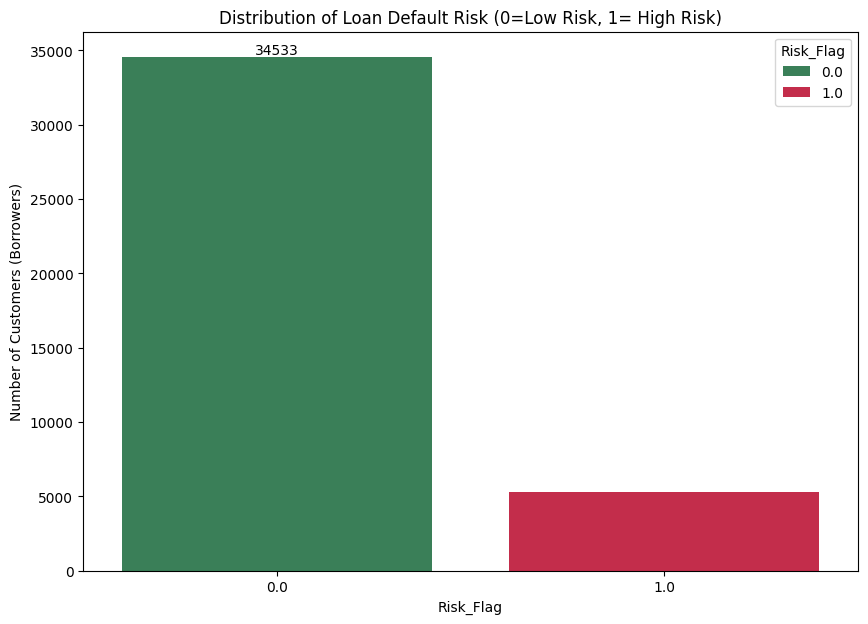

In [10]:
plt.figure(figsize = (10,7))
ax = sns.countplot(x="Risk_Flag", data = df, hue="Risk_Flag", palette={0: "seagreen", 1: "crimson"})
ax.bar_label(ax.containers[0])
plt.title("Distribution of Loan Default Risk (0=Low Risk, 1= High Risk)")
plt.ylabel("Number of Customers (Borrowers)")
plt.show()

**Interpretation:** The visualization shows that there are more safe customers than risky.



### **3.2 Income Distribution Histogram**

**3.2.1** Helps understand income levels of customers and identify financial capacity.


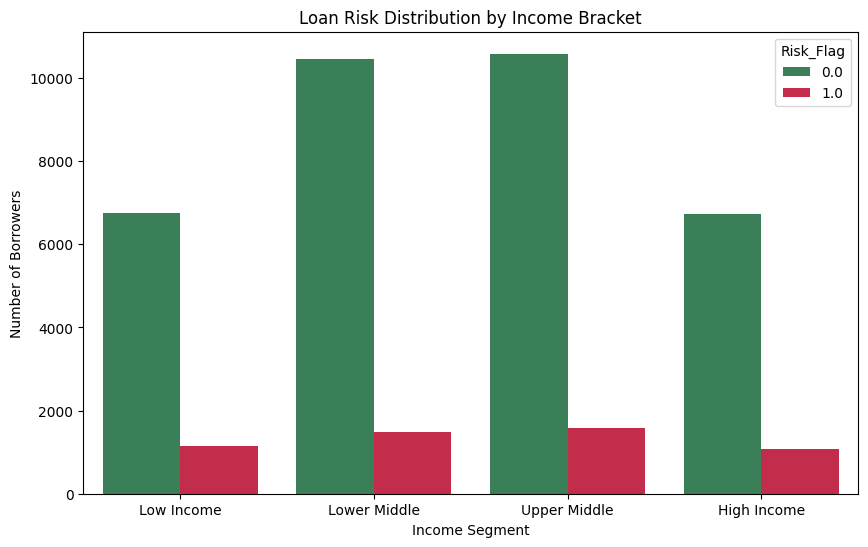

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the labels and the cut-off points (0, 2M, 5M, 8M, 10M)
bins = [0, 2000000, 5000000, 8000000, 10000000]
labels = ['Low Income', 'Lower Middle', 'Upper Middle', 'High Income']

# Create a new column for these ranges
df['Income_Range'] = pd.cut(df['Income'], bins=bins, labels=labels)

# Visualize Risk within these Ranges
plt.figure(figsize=(10, 6))
sns.countplot(x='Income_Range', hue='Risk_Flag', data=df, palette={0: "seagreen", 1: "crimson"})

plt.title("Loan Risk Distribution by Income Bracket")
plt.xlabel("Income Segment")
plt.ylabel("Number of Borrowers")
plt.show()

**Interpretation:** Regardless of whether a customer earns P1 million or P10 million, the risk of them defaulting on a loan is nearly identical.

**3.2.2** Determines if the bank is currently lending to low-income individuals who have a higher statistical probability of defaulting.

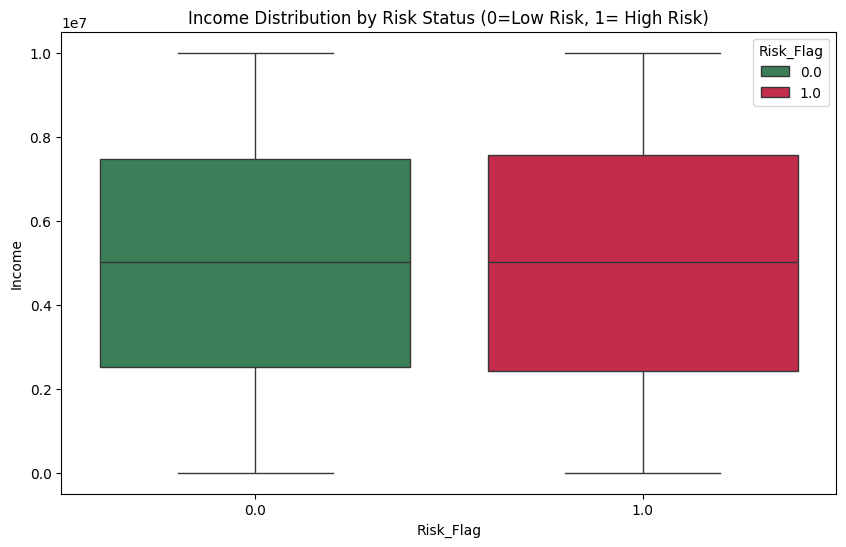

In [12]:
plt.figure(figsize=(10,6))
ax = sns.boxplot(x="Risk_Flag", y ="Income", data = df,hue="Risk_Flag", palette = {0: "seagreen", 1: "crimson"})
plt.title("Income Distribution by Risk Status (0=Low Risk, 1= High Risk)")
plt.show()

**Interpretation:** Income does not determine if someone will default.

I zoomed closely to the image, because i saw a slight difference between the two "boxes", but because the difference was insignificant or subtle, the overall interpretation remains that income does not determine if someone will default.

### **3.3 Age Distribution Histogram**

**3.3.1** Helps understand which age groups apply for loans.


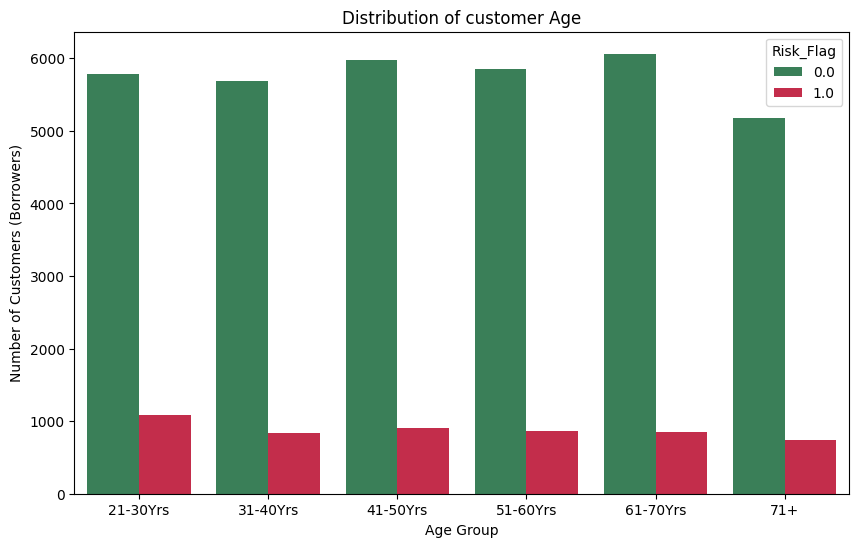

In [13]:
# Define the labels and the cut-off points (0, 2M, 5M, 8M, 10M)
bins = [20, 30, 40, 50, 60, 70, 100]
labels = ['21-30Yrs', '31-40Yrs', '41-50Yrs', '51-60Yrs', '61-70Yrs', '71+']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Age_Group",
    hue="Risk_Flag",
    palette={0: "seagreen", 1: "crimson"}
)

#sns.countplot(x="Age_Group", data = df)
plt.title("Distribution of customer Age")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers (Borrowers)")
plt.show()

**Interpretation:** Age is not a determining factor for loan risk.

In [14]:
df.groupby("Age_Group")["Risk_Flag"].mean()

/tmp/ipykernel_190/891957653.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Risk_Flag"].mean()


,Risk_Flag
Age_Group,
21-30Yrs,0.157626
31-40Yrs,0.127532
41-50Yrs,0.131938
51-60Yrs,0.129128
61-70Yrs,0.122848
71+,0.124535


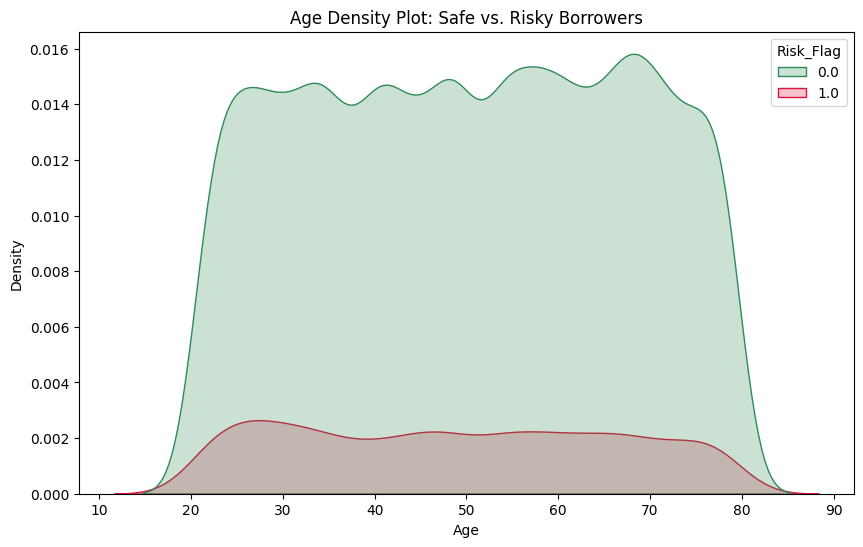

In [15]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="Age", hue="Risk_Flag", fill=True, palette = {0: "seagreen", 1: "crimson"})
plt.title('Age Density Plot: Safe vs. Risky Borrowers')
plt.show()

**Interpretation:** Age is not a determining factor for loan risk.

### **3.4. Marital Status & Risk (Categorical Influence)**

Investigates if being married correlates with better loan repayment behavior.

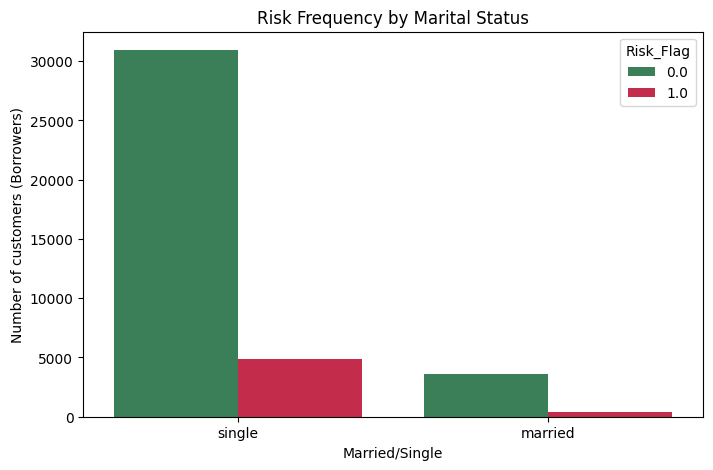

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Married/Single', hue='Risk_Flag', data=df, palette={0: "seagreen", 1: "crimson"})
plt.title('Risk Frequency by Marital Status')
plt.ylabel("Number of customers (Borrowers)")
plt.show()

**Interpretation:** Single customers have a higher number of loan defaults compared to married customers.

In [17]:
df.groupby("Married/Single")["Risk_Flag"].mean()

,Risk_Flag
Married/Single,
married,0.108437
single,0.135199


**Interpretation:** **Married people** have a lower loan default rate of **(8.4%)** compared to **single people** who have a loan default rate of **(15.7%).**

### **3.5. House Ownership vs. Risk (Asset Correlation)**

Renters typically have less collateral than homeowners. This chart proves whether "Rented" status is a significant risk indicator.

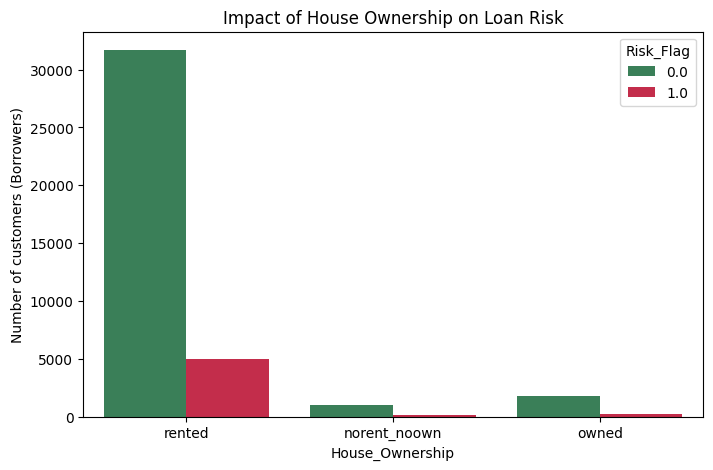

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(x='House_Ownership', hue='Risk_Flag', data=df, palette={0: "seagreen", 1: "crimson"})
plt.title('Impact of House Ownership on Loan Risk')
plt.ylabel("Number of customers (Borrowers)")
plt.show()

**Interpretation:** Customers who rent houses show higher loan default risk compared to those who own houses, suggesting that house ownership is associated with greater financial stability.



---

**Problem:** While the **"Rented"** category shows a significantly higher volume of defaults, this is due to the fact that renters make up roughly 90% of the total customer base. Consequently, this visualization **reflects total quantity rather than the actual risk probability** (the percentage of people within that group who default).





In [19]:
df.groupby("House_Ownership")["Risk_Flag"].mean()

,Risk_Flag
House_Ownership,
norent_noown,0.091393
owned,0.106456
rented,0.135194


**Interpretation:** Initial analysis suggested renters were high-risk; however, after normalizing the data to show default rates, we discovered that renters have a higher default rate than the rest of the categories.

### **3.6 Car Ownership Multi-plot**
Investigates if ownership of secondary assets (like a car) serves as a proxy for financial health.

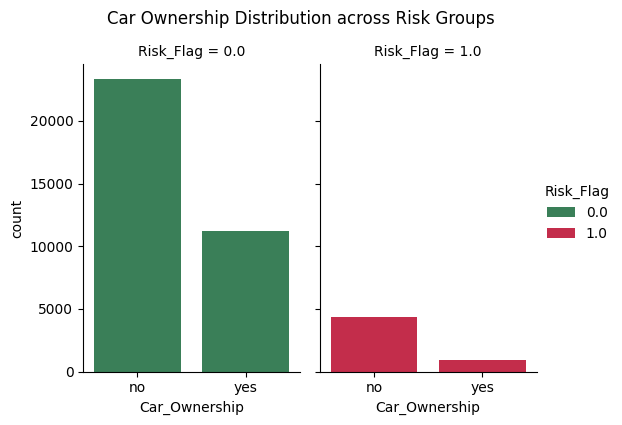

In [20]:
sns.catplot(x="Car_Ownership", col = "Risk_Flag", data = df, hue='Risk_Flag',palette={0: "seagreen", 1: "crimson"},kind = "count", height=4, aspect=.7)
plt.suptitle('Car Ownership Distribution across Risk Groups', y=1.05)
plt.ylabel("Number of customers (Borrowers)")
plt.show()

**Interpretation:** The data is heavily skewed toward low-risk individuals, but the lower ownership rate among high-risk cases suggests a potential correlation between lack of vehicle ownership and higher risk flags.



In [21]:
df.groupby("Car_Ownership")["Risk_Flag"].mean()

,Risk_Flag
Car_Ownership,
no,0.157576
yes,0.074957


**Interpretation:** There is a significant difference in default risk percentage between people who own cars and those who don’t by **8.3%**, which implies that car ownership may serve as a proxy for higher disposable income or greater collateral, both of which typically correlate with a lower likelihood of loan defaulting.


### **3.7 Experience vs. Risk (Professional Stability)**
More experienced people may have more stable income and lower default risk.

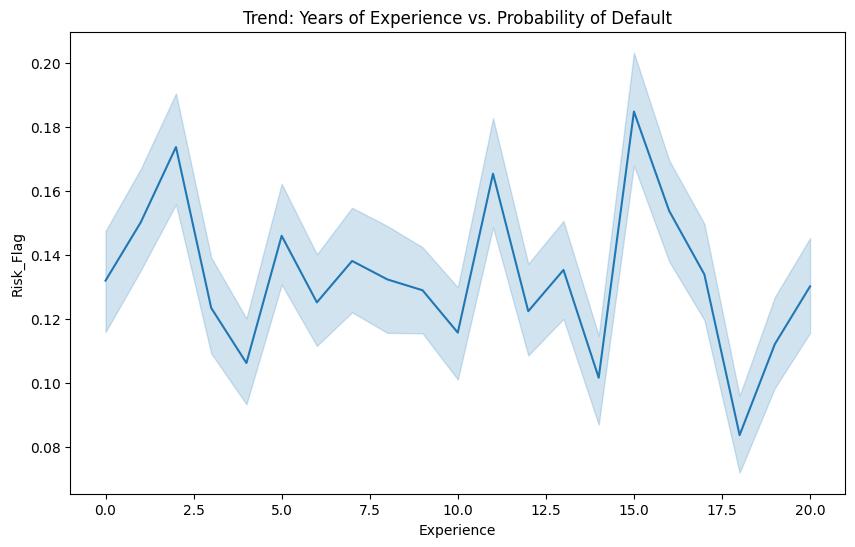

In [22]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Experience', y='Risk_Flag', data=df)
plt.title('Trend: Years of Experience vs. Probability of Default')
plt.show()

**Interpretation:** Experience is not a direct or reliable factor of loan defaulting.

### **3.8 Correlation Heatmap (Feature Selection)**
Shows relationships between variables and identifies factors influencing default risk.

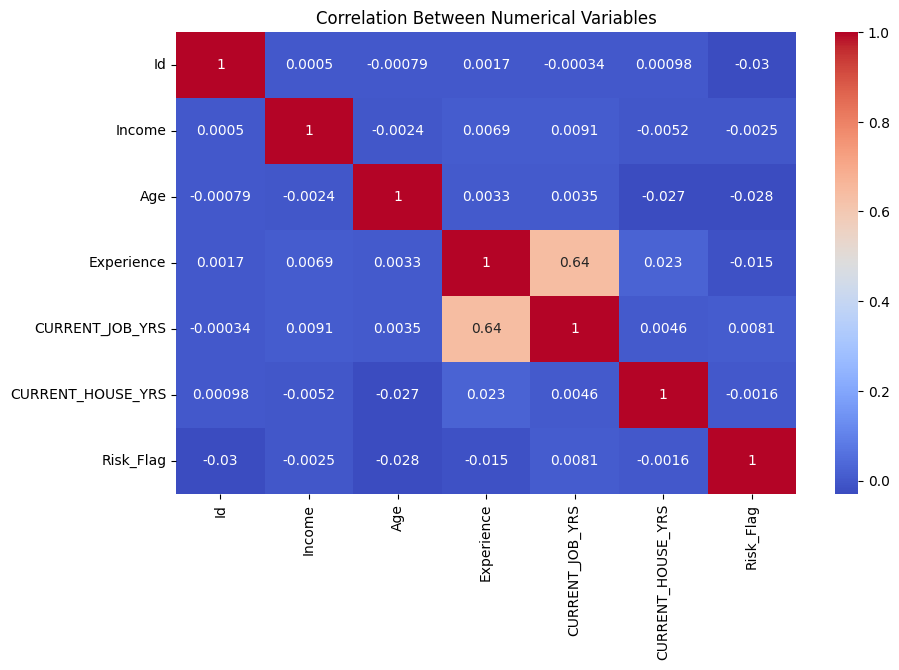

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Between Numerical Variables")
plt.show()

**Interpretation:** The numeric columns have almost no influence on whether a customer is a loan risk.

### **3.9 Current Job Years vs Risk_Flag**
Shows relationships between variables and identifies factors influencing default risk.

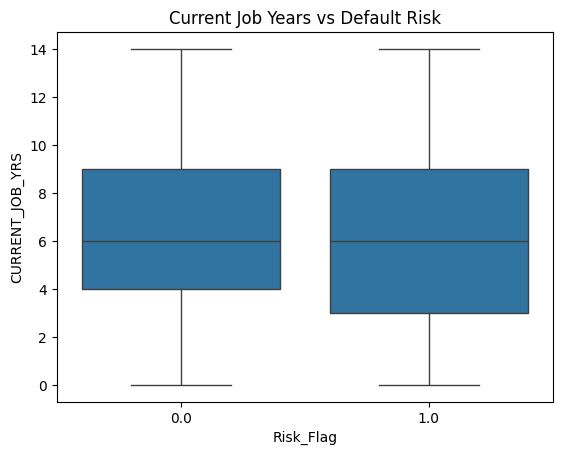

In [24]:
sns.boxplot(x="Risk_Flag", y="CURRENT_JOB_YRS", data=df)
plt.title("Current Job Years vs Default Risk")
plt.show()

**Interpretation:** Experience is not a direct or reliable factor of loan defaulting.

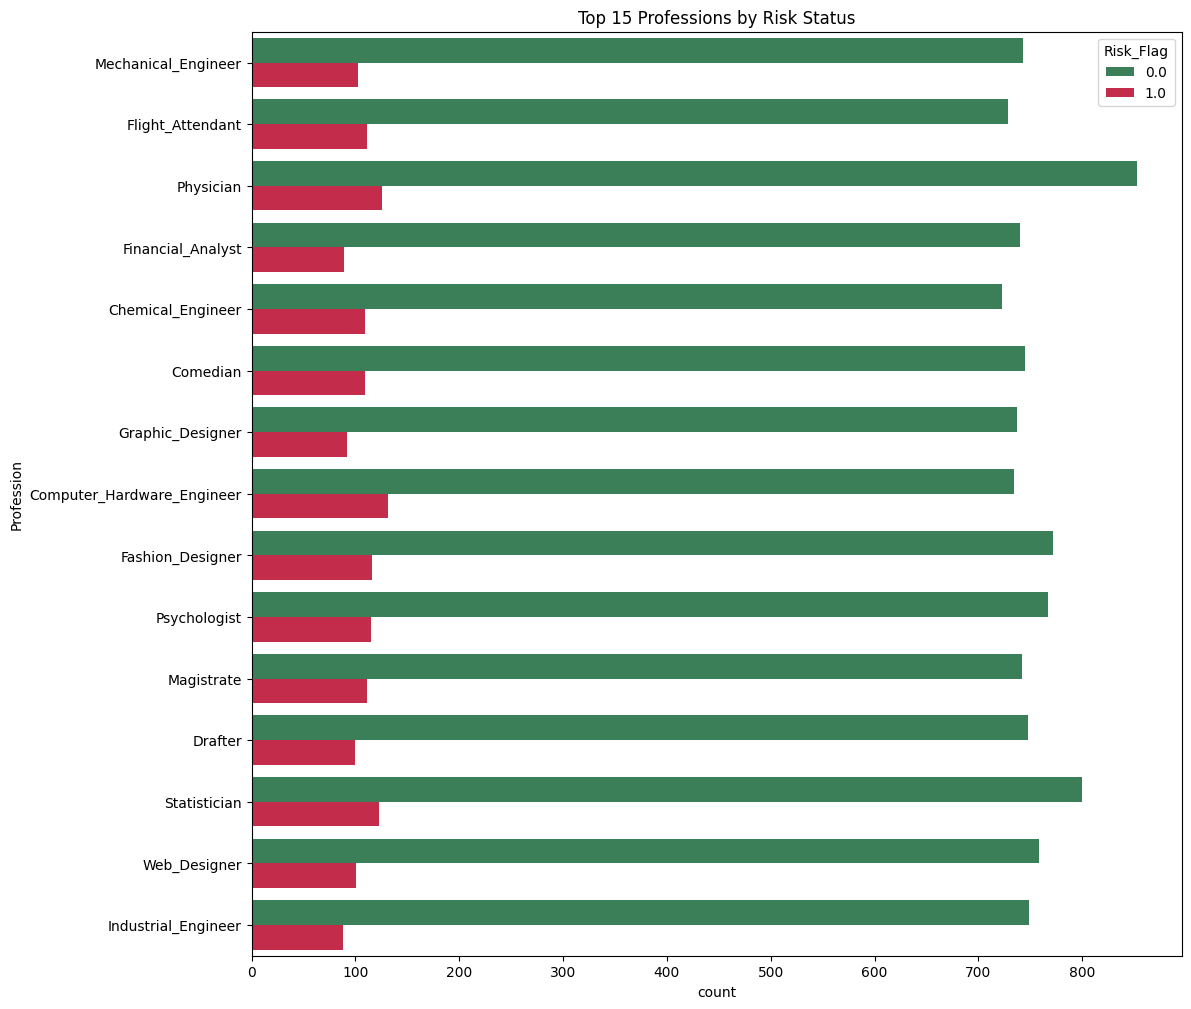

In [25]:
plt.figure(figsize=(12, 12))
# Taking top 15 professions for clarity
top_professions = df['Profession'].value_counts().head(15).index
sns.countplot(y='Profession', hue='Risk_Flag', data=df[df['Profession'].isin(top_professions)], palette={0: "seagreen", 1: "crimson"})
plt.title('Top 15 Professions by Risk Status')
plt.show()

In [26]:
df.groupby("Profession")["Risk_Flag"].mean().head()

,Risk_Flag
Profession,
Air_Traffic_Controller,0.143032
Analyst,0.126214
Architect,0.146341
Army_Officer,0.187929
Artist,0.129973


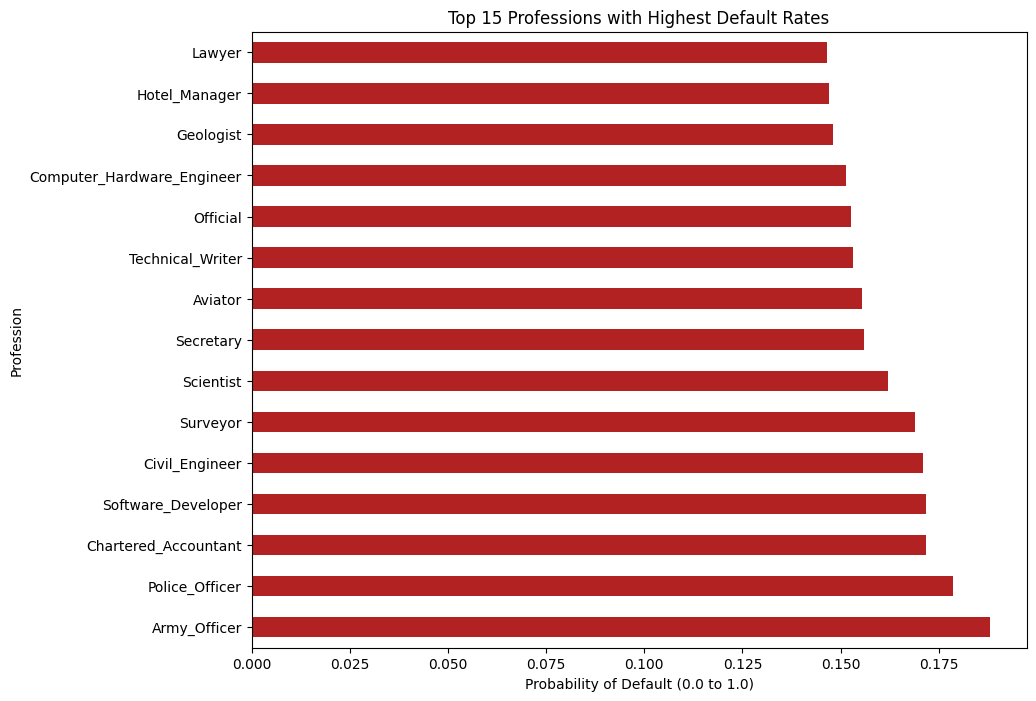

In [27]:
# Calculate the percentage of risk per profession
profession_risk = df.groupby('Profession')['Risk_Flag'].mean().sort_values(ascending=False).head(15)

# Plotting
plt.figure(figsize=(10, 8))
profession_risk.plot(kind='barh', color='firebrick')
plt.title('Top 15 Professions with Highest Default Rates')
plt.xlabel('Probability of Default (0.0 to 1.0)')
plt.show()

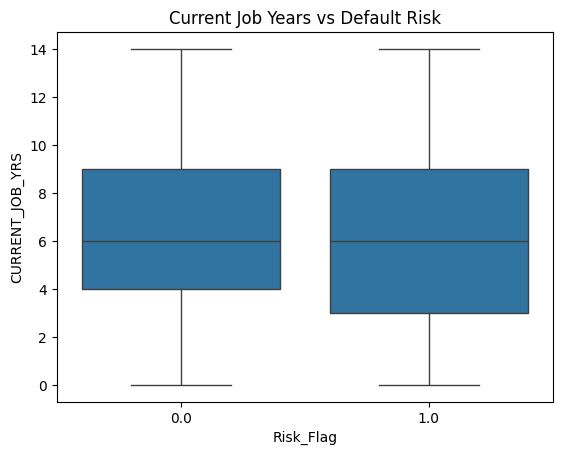

In [28]:
sns.boxplot(x="Risk_Flag", y="CURRENT_JOB_YRS", data=df)
plt.title("Current Job Years vs Default Risk")
plt.show()

In [29]:
# Bins for Job Years
df['Job_Tenure_Group'] = pd.cut(df['CURRENT_JOB_YRS'], bins=[0, 3, 7, 11, 15], labels=['Entry', 'Junior', 'Senior', 'Veteran'])

# Risk for each group
df.groupby('Job_Tenure_Group')[['Risk_Flag']].mean()

/tmp/ipykernel_190/2806004180.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Job_Tenure_Group')[['Risk_Flag']].mean()


,Risk_Flag
Job_Tenure_Group,
Entry,0.135893
Junior,0.126492
Senior,0.136452
Veteran,0.138159


**Interpretation:** Current Job Years slightly influences default risk.

**Conclusion:** Exploratory data analysis revealed that financial stability indicators are the strongest predictors of loan default risk. Customers who rent homes or lack car ownership exhibit significantly higher default rates, suggesting asset ownership is closely linked to lower risk. Profession-based differences further indicate that employment type influences repayment behavior. While age and marital status show moderate variation, they are less predictive on their own. Overall, income, job stability, and asset ownership are the most influential factors.

## **4. Machine Learning Model (Logistic Regression)**



### **4.1 Data Pre-Processing**


In [56]:
#1. Missing value Treatments
df.isnull().sum()

,0
Id,0
Income,0
Age,0
Experience,0
Married/Single,0
House_Ownership,0
Car_Ownership,0
Profession,0
CITY,0
STATE,0


There's one missing value from the Risk_Flag Column (Target), so I removed the row before training the model. Imputation cannot work in this case because Risk_Flag is a categorical column, so filling it with the average, might lead to a number like 0.13 which isn't categorical.  

In [31]:
df.dropna(subset=["Risk_Flag"], inplace=True)

In [32]:
df["Risk_Flag"].isnull().sum()

np.int64(0)

In [33]:
3. #Checking for duplicates
df.duplicated().sum()

np.int64(0)

**Output:** No duplicated values

In [34]:
#We want to first divide the data into numerical and categorical columns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [35]:
df.columns

Index(['Id', 'Income', 'Age', 'Experience', 'Married/Single',
       'House_Ownership', 'Car_Ownership', 'Profession', 'CITY', 'STATE',
       'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Risk_Flag', 'Income_Range',
       'Age_Group', 'Job_Tenure_Group'],
      dtype='object')

### **4.2 Separate features and target**

In [36]:
X = df[["Income", "Age", "Experience", "Married/Single", "House_Ownership", "Car_Ownership", "Profession", "CITY", "STATE", "CURRENT_JOB_YRS", "CURRENT_HOUSE_YRS"]]
# OR X = df.drop("Risk_Flag", axis=1)
y = df["Risk_Flag"]

In [37]:
X

,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS
0,1303834,23,3,single,rented,no,Mechanical_Engineer,Rewa,Madhya_Pradesh,3.0,13.0
1,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9.0,13.0
2,3991815,66,4,married,rented,no,Technical_Writer,Alappuzha,Kerala,4.0,10.0
3,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2.0,12.0
4,5768871,47,11,single,rented,no,Civil_Servant,Tiruchirappalli,Tamil_Nadu,3.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...
39802,8964405,67,15,single,rented,no,Surgeon,Kavali,Andhra_Pradesh,8.0,10.0
39803,3246861,79,2,single,rented,yes,Aviator,Adoni,Andhra_Pradesh,2.0,13.0
39804,1478769,22,14,single,rented,no,Secretary,Shimla,Himachal_Pradesh,8.0,12.0
39805,9541394,22,15,single,rented,yes,Scientist,Rewa,Madhya_Pradesh,12.0,11.0


In [38]:
#For categorical columns with low cardinality(few unique values) we will use One- Hot Encoding
cat_cols_LC = ["Married/Single", "House_Ownership", "Car_Ownership"]

#for ones with high cardinality, we will use target encoding
cat_cols_HC = ["Profession", "CITY", "STATE"]

In [39]:
df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,Income_Range,Age_Group,Job_Tenure_Group
0,1,1303834,23,3,single,rented,no,Mechanical_Engineer,Rewa,Madhya_Pradesh,3.0,13.0,0.0,Low Income,21-30Yrs,Entry
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9.0,13.0,0.0,Upper Middle,31-40Yrs,Senior
2,3,3991815,66,4,married,rented,no,Technical_Writer,Alappuzha,Kerala,4.0,10.0,0.0,Lower Middle,61-70Yrs,Junior
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2.0,12.0,1.0,Upper Middle,41-50Yrs,Entry
4,5,5768871,47,11,single,rented,no,Civil_Servant,Tiruchirappalli,Tamil_Nadu,3.0,14.0,1.0,Upper Middle,41-50Yrs,Entry


In [40]:
#first let us find the cardinality of those particular columns
df.Profession.value_counts()

,count
Profession,
Physician,979
Statistician,923
Fashion_Designer,888
Psychologist,882
Computer_Hardware_Engineer,865
Web_Designer,859
Comedian,854
Magistrate,853
Drafter,848


In [41]:
#cardinality for city
df.CITY.value_counts()

,count
CITY,
Aurangabad,241
Bulandshahr,205
Vijayanagaram,202
Bhopal,201
Saharsa,198
...,...
Bettiah,64
Ujjain,64
Katni,64


In [42]:
#cardinality for state
df.STATE.value_counts()

,count
STATE,
Uttar_Pradesh,4645
Maharashtra,4054
Andhra_Pradesh,3984
West_Bengal,3697
Bihar,3129
Tamil_Nadu,2621
Madhya_Pradesh,2208
Karnataka,1871
Gujarat,1820


### **4.3 TRAIN-TEST SPLIT**
Doing a train-test split before encoding is critical to prevent data leakage, ensuring that the model does not gain information from the test set during training

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

### **4.4 APPLYING TARGET ENCODING TO THE HIGH CARDINALITY COLUMNS**

In [44]:
for col in cat_cols_HC:

  # calculate mean risk per category using TRAINING data only
    target_means = X_train.groupby(col)[col].apply(
        lambda x: y_train[x.index].mean()
    )

    # map to training data
    X_train[col] = X_train[col].map(target_means)

    # map to test data (use training means only)
    X_test[col] = X_test[col].map(target_means)


In [45]:
#Some cities / professions may not exist in the training data

global_mean = y_train.mean()

X_train[cat_cols_HC] = X_train[cat_cols_HC].fillna(global_mean)
X_test[cat_cols_HC] = X_test[cat_cols_HC].fillna(global_mean)

### **4.5 APPLYING ONE HOT ENCODING TO LOW CARDINALITY COLUMNS**

In [46]:
X_train = pd.get_dummies(X_train, columns=cat_cols_LC, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols_LC, drop_first=True)

### **4.6 ALIGN TRAIN AND TEST COLUMNS**

In [47]:
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

### **4.7 SCALING THE DATA**

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **4.8 TRAIN THE LOGISTIC REGRESSION MODEL**

In [49]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

## **5. Model Evaluation**



In [50]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score

# Model 1

# Standard order: (True labels, Predicted labels)
lr_prediction = model.predict(X_test)
accuracy1 = accuracy_score(y_test, lr_prediction)
print(f"Logistic Regression 1 Accuracy: {accuracy1}")

Logistic Regression 1 Accuracy: 0.6375282592313489


**Conclusion:** The model correctly classified 63.5% of all customers. However, accuracy alone can be misleading due to class imbalance.

**Accuracy** = (TP + TN)/ (TP+TN+FN+FP)

In [51]:
#2. PRECISION
precision_m1 = precision_score(y_test, lr_prediction)
print(f"Model 1 Precision Score: {precision_m1 }")

Model 1 Precision Score: 0.20647643475472907


**Conclusion:** Only 21.5% of the customers predicted as high-risk were actually risky. This indicates a relatively high number of false positives.

**Precision** = TP / TP + TN

In [52]:
#3 RECALL(SENSITIVITY)
recall_score_m1 = recall_score(y_test, lr_prediction)
print(f"Model 1 Recall Score: {recall_score_m1}")

Model 1 Recall Score: 0.6104265402843602


**Conclusion:** The model successfully identified 61.7% of actual high-risk customers. This is important because it shows the model is reasonably effective at detecting risky borrowers.


In [53]:
#4 f1_score
f1_score_m1 = f1_score(y_test, lr_prediction)
print(f"Model 1 Recall Score: {f1_score_m1}")

Model 1 Recall Score: 0.30857690464781984


**Conclusion:** The F1-score balances precision and recall. A score of 31.8% indicates that while recall is moderate, low precision reduces overall performance balance.

In [54]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_prediction)
print(cm)

[[4432 2475]
 [ 411  644]]


**Conclusion** : The model can be improved by trying more advanced algorithms and improving how the data is prepared. Handling class imbalance better may help increase precision. Adding more relevant financial features could also improve predictions. The model should support decision-making, not replace human judgment.


**The code below serves as an example of how the Random Forest Classifier would perform in comparison with the linear model.**

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

accuracy5 = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy5}")

[[6457  450]
 [ 106  949]]
              precision    recall  f1-score   support

         0.0       0.98      0.93      0.96      6907
         1.0       0.68      0.90      0.77      1055

    accuracy                           0.93      7962
   macro avg       0.83      0.92      0.87      7962
weighted avg       0.94      0.93      0.93      7962

Random Forest Accuracy: 0.9301682994222558
